# 📊 Seaborn Part 2 — Categorical, Regression & Multi-Panel Grids

**Topic:** 08.04 · **Level:** 🟠 Intermediate · **Type:** THEORY + CODE

## What this notebook covers

In Session 25 you met Seaborn's relational, distribution and matrix plot families. These all treat the data as points to scatter, densities to trace or grids to color. Part 2 tackles the plots you reach for when **one of your variables is categorical** (sex, day, smoker) — plus regression plots and the grid objects that let one figure hold many small panels. Everything runs on the built-in `tips` and `iris` datasets.

We start with **categorical plots**, which split into three groups. *Categorical scatter* — `stripplot`, `swarmplot` — puts every data point over a categorical axis; the trick is `jitter` (random horizontal offsets so overlapping points separate) or a beeswarm algorithm that packs points without overlap. *Categorical distribution* — `boxplot` and `violinplot` — summarize each category with quartiles or with a box-plus-density shape. *Categorical estimate* — `barplot`, `pointplot`, `countplot` — reduce each group to a statistic (mean, median, count) and draw bars or points with error bars. Because all of these use the same categorical x-axis, Seaborn bundles them behind one figure-level function: `sns.catplot(kind='strip' | 'swarm' | 'box' | 'violin' | 'bar' | 'point' | 'count', ...)`. The golden rule: a categorical plot has a **categorical** x (or y) and usually a **numeric** y.

The notebook then moves to **regression plots**, where the goal is no longer description but modelling: `regplot` draws a scatter plus the best-fit line and a 95% confidence band; `lmplot` is the figure-level version with `hue` and faceting; `residplot` plots the residuals (distance between points and line) to check whether a straight line was a fair assumption.

Finally come the **grid objects** — multi-panel machinery. `FacetGrid` is a manual grid of panels arranged by `col`, `row` and `hue` onto which you `map` a plotting function. `PairGrid` creates a matrix of every numeric-variable pair, letting you choose separate plots for the diagonal (`map_diag`), upper (`map_upper`) and lower (`map_lower`) triangles — `pairplot` is its one-line default. `JointGrid` combines a 2D plot with univariate marginals on the edges — `jointplot` is its default. The notebook closes with `sns.get_dataset_names()` and `sns.load_dataset()`, your access to Seaborn's built-in datasets.

In [1]:
import seaborn as sns

In [2]:
# import datasets
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')

## Categorical Plots

### Categorical Scatter Plot

- Stripplot
- Swarmplot

### Categorical Distribution Plots

- Boxplot
- Violinplot

### Categorical Estimate Plot -> for central tendency

- Barplot
- Pointplot
- Countplot

### Figure level function -> `catplot`

### Recap — the relational scatter, now with tips

Cell 3 opens your categorical session with a familiar sight: `sns.scatterplot(data=tips, x='total_bill', y='tip')`. This is the exact relational plot from Session 25 — one point per dinner bill, total amount spent on the x-axis against the tip on the y-axis. Hold this image in your head. As you scroll through the notebook, notice how the very same `tips` data gets progressively richer treatments: first the raw scatter, then the categorical scatter that compresses the x-axis into a few categories, then boxplots that summarize those categories, and finally regression lines that model the trend. Each new plot is one more step up the ladder from *raw points* → *grouped points* → *distribution summaries* → *statistical estimates* → *models*. Watch for the moment when the scatter of all the points becomes a swarm of dots per eating time-of-day (`day`): that transition is the heart of this notebook.

<Axes: xlabel='total_bill', ylabel='tip'>

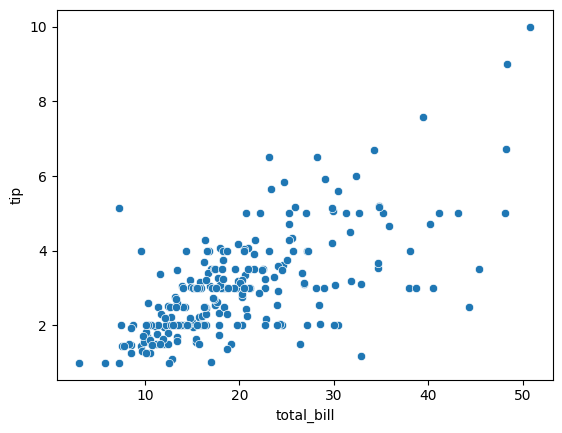

In [3]:
sns.scatterplot(data=tips, x='total_bill',y='tip')

## 🔬 Deep Dive : Regression plots — regplot/lmplot/residplot

```python
sns.regplot(data=tips, x='total_bill', y='tip')     # scatter + fitted line
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex')   # facets
sns.residplot(data=tips, x='total_bill', y='tip')   # residuals
```

- regplot — scatter + linear regression line + CI band
- lmplot — figure-level regression with hue/facets
- residplot — fit at residuals vs x (model fit check)
- Visual model relationship strength
- hue in lmplot not available in regplot
- outliers influence regression line visibly
- ci — confidence interval shading
- order= / logistic variants (nonlinear)
- pair plots with reg kind extensions
- Quick hypothesis visual validation

## 🔬 Deep Dive : Categorical plots — strip/swarm

```python
sns.catplot(data=tips, x='day', y='total_bill', kind='strip', jitter=0.2, hue='sex')
sns.catplot(data=tips, x='day', y='total_bill', kind='swarm')
```

- catplot — FIGURE-level for categorical x
- kinds: strip, swarm, box, violin, boxen, point, bar, count
- strip — every point raw; jitter offsets overlaps
- swarm — points avoid overlap (beeswarm)
- hue — split color per category inside group
- one categorical + one numerical → distribution comparison per category
- overlay many obs → see exact spread & clusters
- vs scatterplot — categorical axis compressed
- swarm best clarity <200 pts
- axes-level variants: sns.stripplot / sns.swarmplot

<Axes: xlabel='day', ylabel='total_bill'>

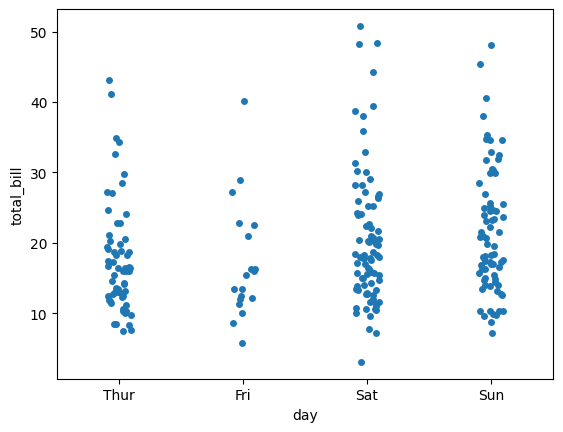

In [4]:
# strip plot
# axes level function
sns.stripplot(data=tips,x='day',y='total_bill')

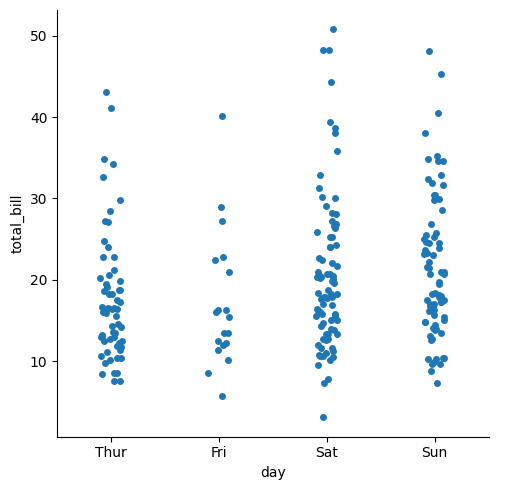

In [5]:
# using catplot
# figure level function
sns.catplot(data=tips, x='day',y='total_bill',kind='strip')

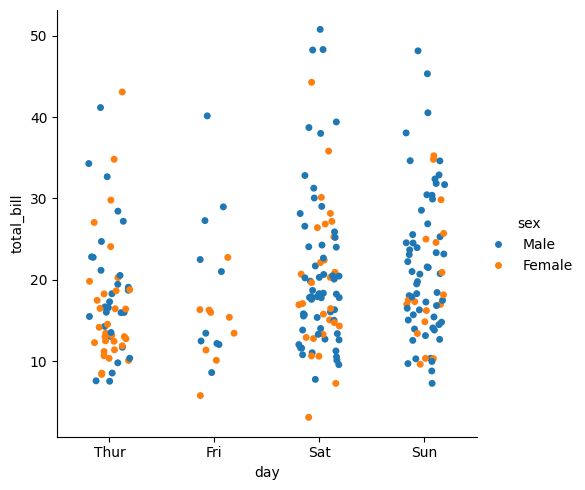

In [6]:
# jitter
sns.catplot(data=tips, x='day',y='total_bill',kind='strip',jitter=0.2,hue='sex')

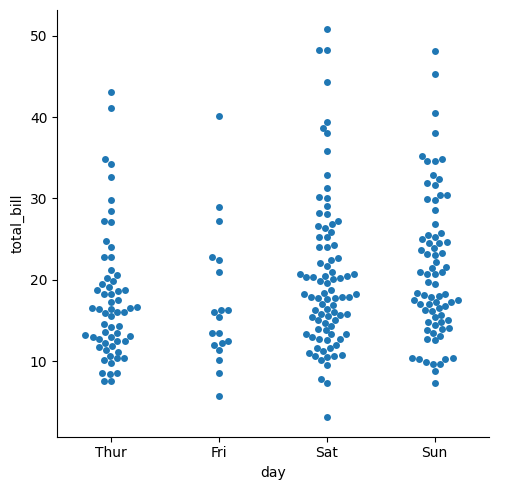

In [7]:
# swarmplot
sns.catplot(data=tips, x='day',y='total_bill',kind='swarm')

<Axes: xlabel='day', ylabel='total_bill'>

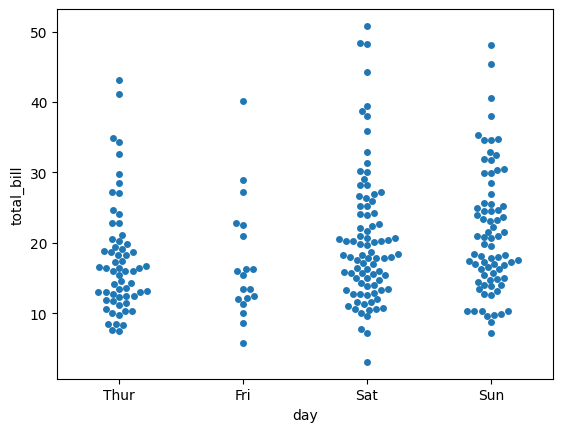

In [8]:
sns.swarmplot(data=tips, x='day',y='total_bill')

<Axes: xlabel='day', ylabel='total_bill'>

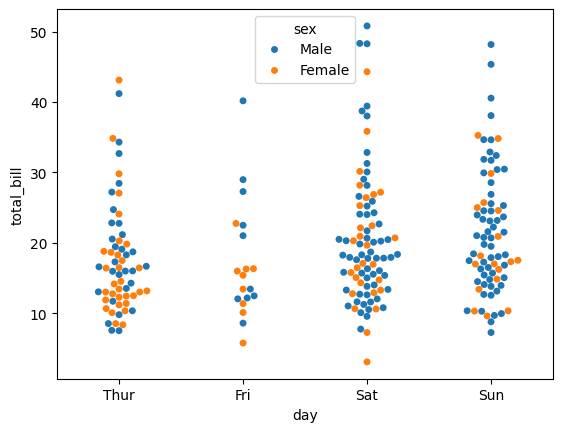

In [9]:
# hue
sns.swarmplot(data=tips, x='day',y='total_bill',hue='sex')

### Boxplot

A boxplot is a standardized way of displaying the distribution of data based on a five number summary (“minimum”, first quartile [Q1], median, third quartile [Q3] and “maximum”). It can tell you about your outliers and what their values are. Boxplots can also tell you if your data is symmetrical, how tightly your data is grouped and if and how your data is skewed.

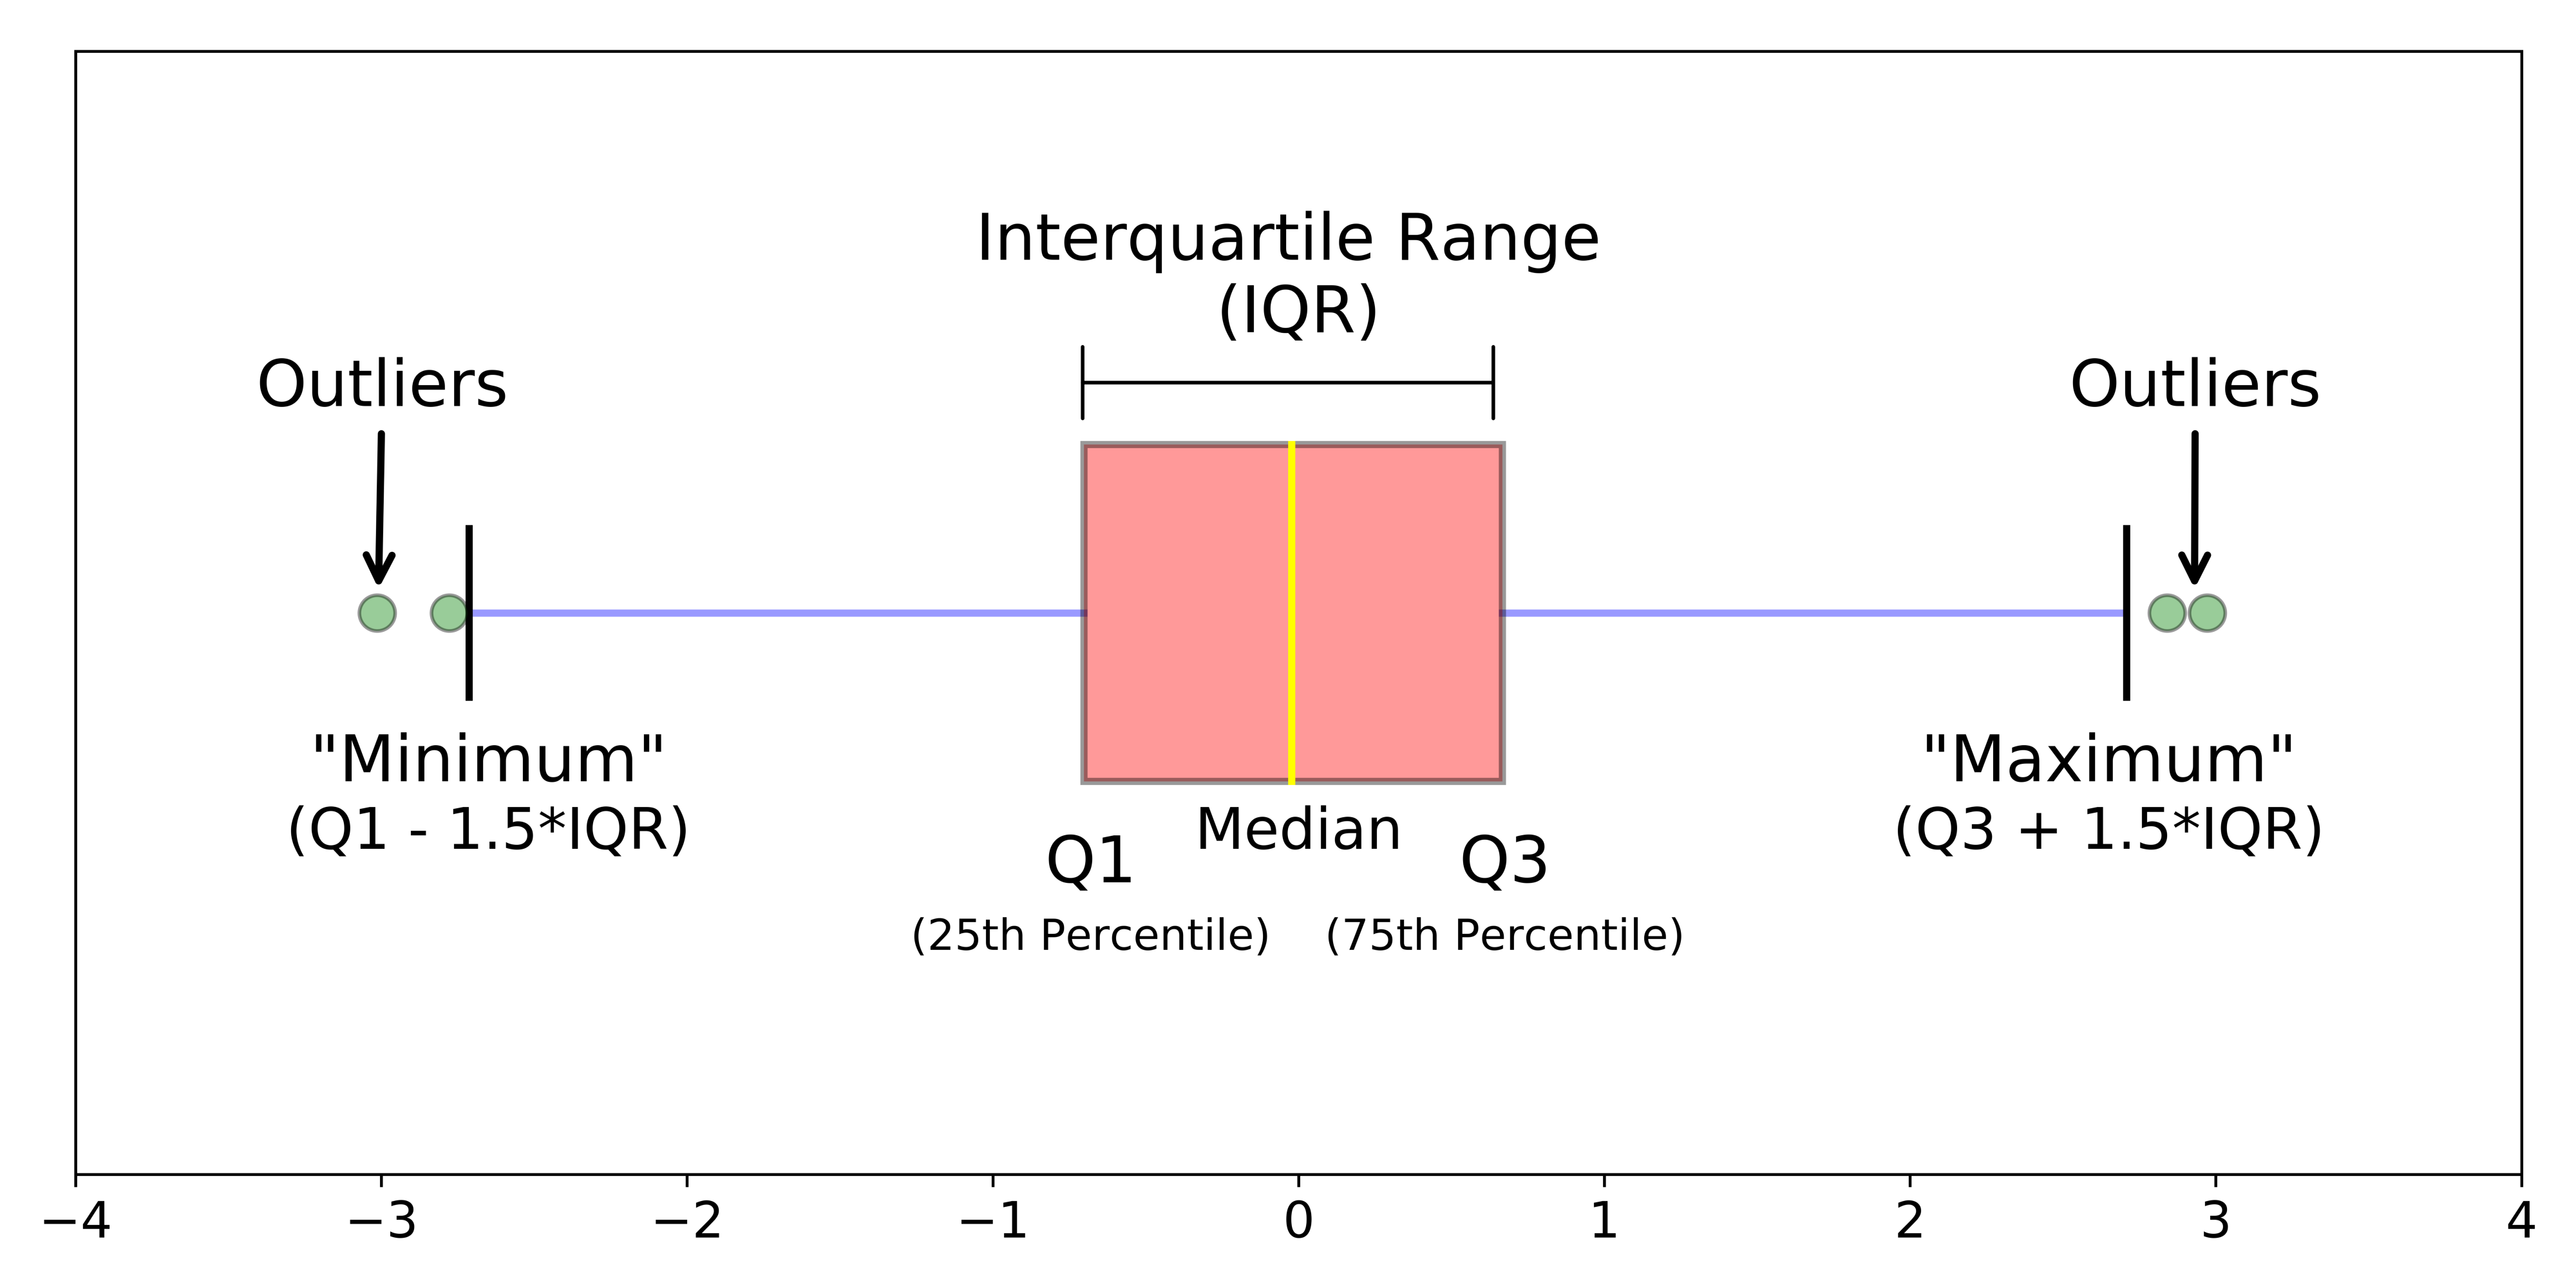

## 🔬 Deep Dive : Box plots — 5-number summary

```python
sns.boxplot(data=tips, x='day', y='total_bill')
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex')
sns.boxplot(data=tips, y='total_bill')      # single numeric
sns.catplot(data=tips, x='day', y='total_bill', kind='box')
```

- Box: min, Q1, median, Q3, max (whiskers = 1.5*IQR)
- Points beyond whiskers = OUTLIERS
- Box width = IQR; line inside = median
- catplot kind='box' — figure-level facets
- hue — separate box per subclass (day×sex)
- Single numeric — one box overall
- IQR = Q3 − Q1; whisker bounds standard
- Compare medians across categories
- Better than bar: full distribution summary
- Data cleaning check: outliers visible

<Axes: xlabel='day', ylabel='total_bill'>

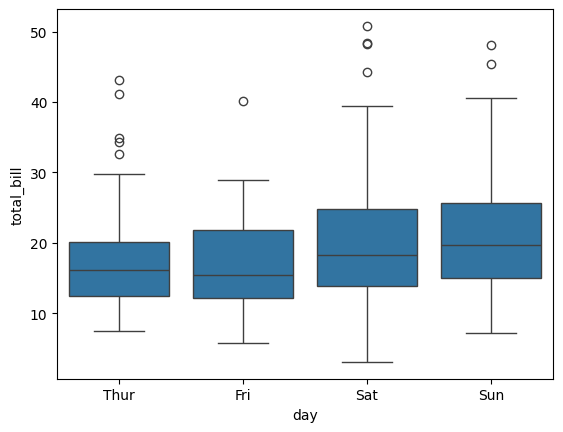

In [10]:
# Box plot
sns.boxplot(data=tips,x='day',y='total_bill')

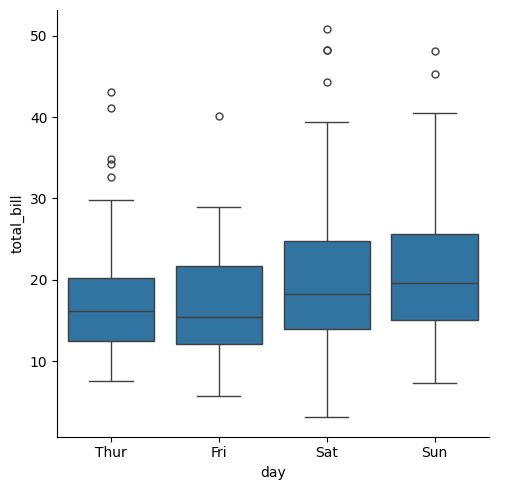

In [11]:
# Using catplot
sns.catplot(data=tips,x='day',y='total_bill',kind='box')

<Axes: xlabel='day', ylabel='total_bill'>

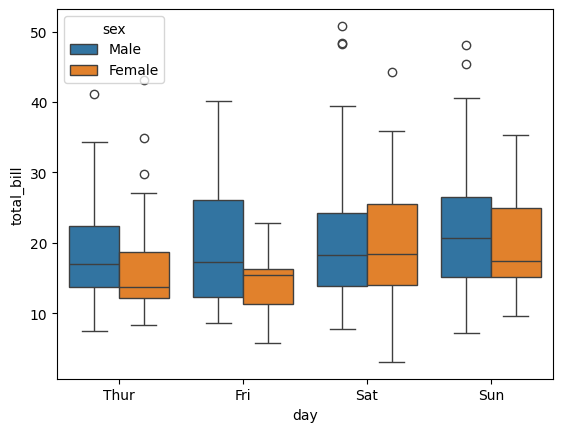

In [12]:
# hue
sns.boxplot(data=tips,x='day',y='total_bill',hue='sex')

<Axes: ylabel='total_bill'>

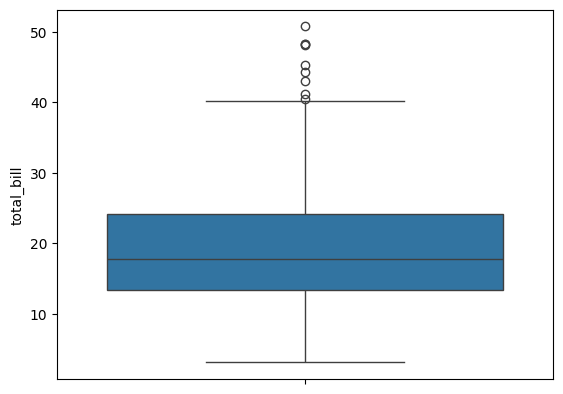

In [13]:
# single boxplot -> numerical col
sns.boxplot(data=tips,y='total_bill')

### Violinplot = (Boxplot + KDEplot)

## 🔬 Deep Dive : Violin — box + density

```python
sns.violinplot(data=tips, x='day', y='total_bill')
sns.catplot(data=tips, x='day', y='total_bill', kind='violin', hue='sex', split=True)
```

- Violin = boxplot + KDE — distribution shape + stats
- Width of violin = density of points
- Inside: mini boxplot (median, IQR)
- One distribution per category
- split=True — hue two sides same violin
- Shows multimodal shapes boxes miss
- Check skew/peaks/bimodal
- Better insight than plain box
- ci/bootstrap irrelevant
- cautious subset: catplot facet combination

<Axes: xlabel='day', ylabel='total_bill'>

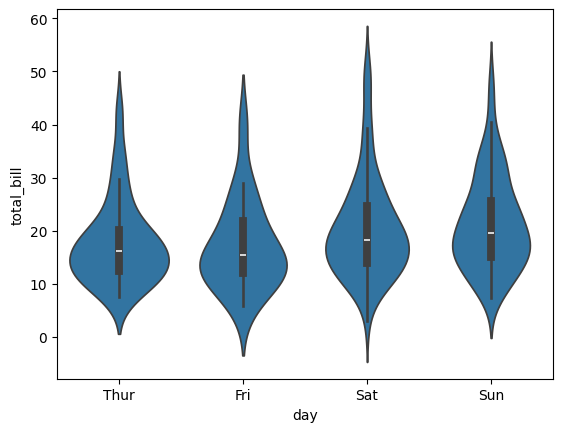

In [14]:
# violinplot
sns.violinplot(data=tips,x='day',y='total_bill')

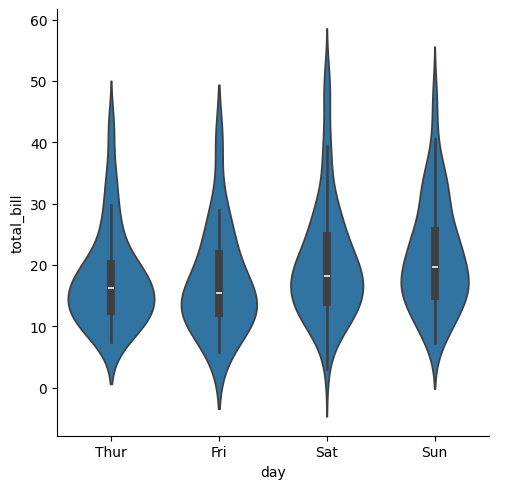

In [15]:
sns.catplot(data=tips,x='day',y='total_bill',kind='violin')

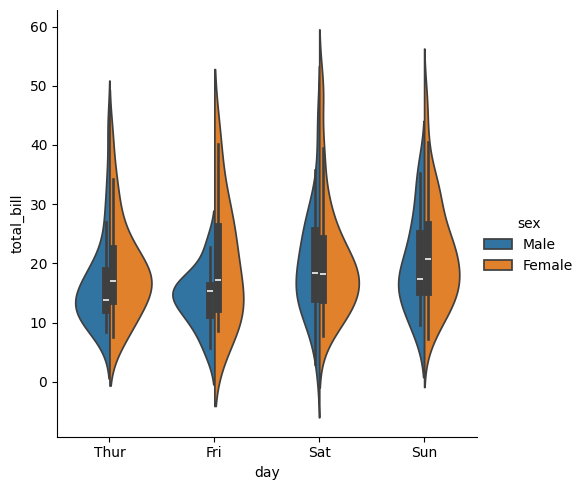

In [16]:
# hue

sns.catplot(data=tips,x='day',y='total_bill',kind='violin',hue='sex',split=True)

## 🔬 Deep Dive : barplot / pointplot / countplot

```python
sns.barplot(data=tips, x='sex', y='total_bill', ci=None)      # mean bar
sns.pointplot(data=tips, x='sex', y='total_bill', hue='smoker', ci=None)
sns.countplot(data=tips, x='sex', hue='day')                   # counts
sns.catplot(data=tips, x='sex', y='total_bill', col='smoker', kind='bar')
```

- barplot — mean of y per category + error bar
- pointplot — mean points + confidence lines (trend across cats)
- countplot — COUNT observations (no y needed) — histogram categorical
- ci/errorbar: None disables confidence interval
- stat='median'/'sum' alternatives
- hue — subclassed bars
- Categorical summary — where shall values per group
- bar vs histogram vs count: bar=agg value, count=number rows
- Use distribution first, summary second
- Statistical aggregates encode messages

<Axes: xlabel='sex', ylabel='total_bill'>

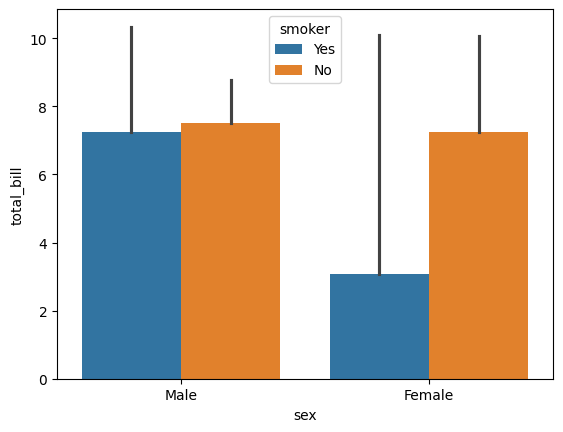

In [17]:
# barplot
# some issue with errorbar
import numpy as np
sns.barplot(data=tips, x='sex', y='total_bill',hue='smoker',estimator=np.min)

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_19796\3522951494.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tips, x='sex', y='total_bill',ci=None)


<Axes: xlabel='sex', ylabel='total_bill'>

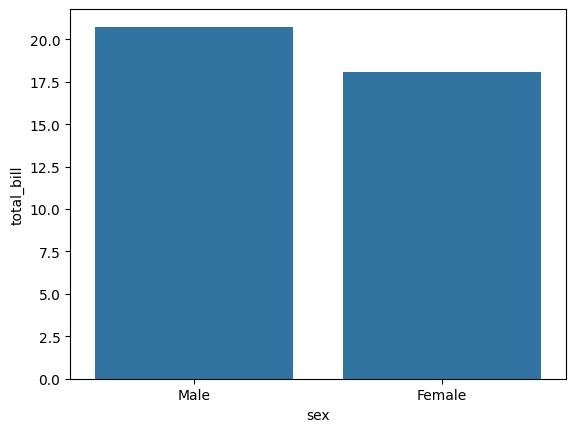

In [18]:
sns.barplot(data=tips, x='sex', y='total_bill',ci=None)

C:\Users\RAVNOOR SINGH\AppData\Local\Temp\ipykernel_19796\2657825262.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=tips, x='sex', y='total_bill',hue='smoker',ci=None)


<Axes: xlabel='sex', ylabel='total_bill'>

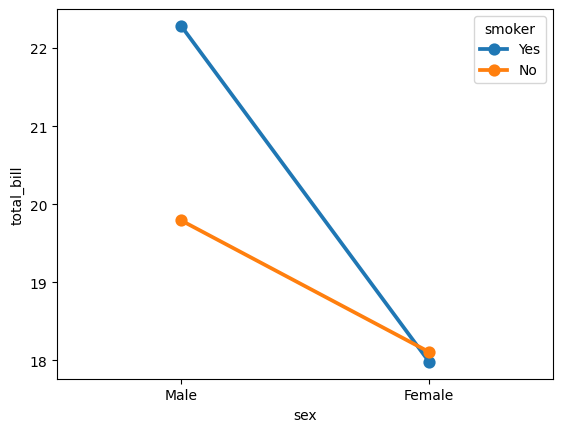

In [19]:
# point plot
sns.pointplot(data=tips, x='sex', y='total_bill',hue='smoker',ci=None)

When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars

<Axes: xlabel='sex', ylabel='count'>

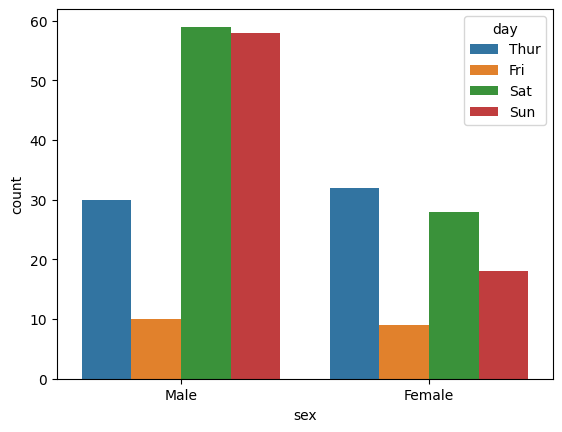

In [20]:
# countplot
sns.countplot(data=tips,x='sex',hue='day')

A special case for the bar plot is when you want to show the number of observations in each category rather than computing a statistic for a second variable. This is similar to a histogram over a categorical, rather than quantitative, variable

In [21]:
# pointplot

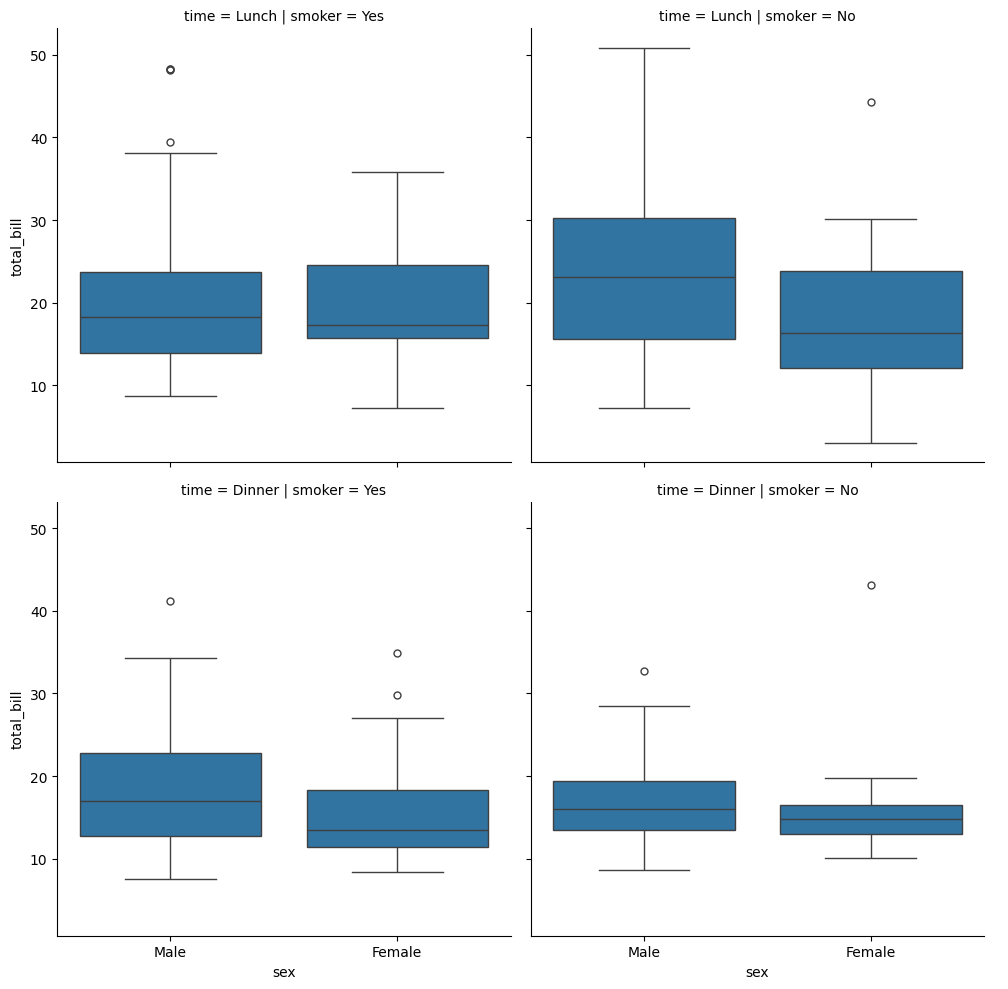

In [22]:
# faceting using catplot
sns.catplot(data=tips, x='sex',y='total_bill',col='smoker',kind='box',row='time')

### Regression Plots

- regplot
- lmplot

In the simplest invocation, both functions draw a scatterplot of two variables, x and y, and then fit the regression model y ~ x and plot the resulting regression line and a 95% confidence interval for that regression.

### Regression plots — regplot, lmplot, residplot

A natural step after describing data is to *model* it. `sns.regplot(data, x='total_bill', y='tip')` draws the scatter and then fits a simple linear regression `tip ~ total_bill`, plotting the fitted line plus a shaded 95% confidence band for the mean. `regplot` is an **axes-level** function — it draws on the current axes and therefore has *no* `hue` parameter. `sns.lmplot(...)` is its **figure-level** sibling: it builds a `FacetGrid` internally, so it accepts `hue`, `col` and `row`, and is the right choice when you want separate regression lines per group (here, per `sex`). `sns.residplot(data, x='total_bill', y='tip')` plots the **residuals** on the y-axis — every point's vertical distance from the regression line. If the residuals form a random cloud around zero, a straight line is a good fit; if they curve or fan out, linearity or constant variance is violated. These three plots are your first look at inference: not just *what* the data looks like, but *how strongly* and *how well* two variables relate.

<Axes: xlabel='total_bill', ylabel='tip'>

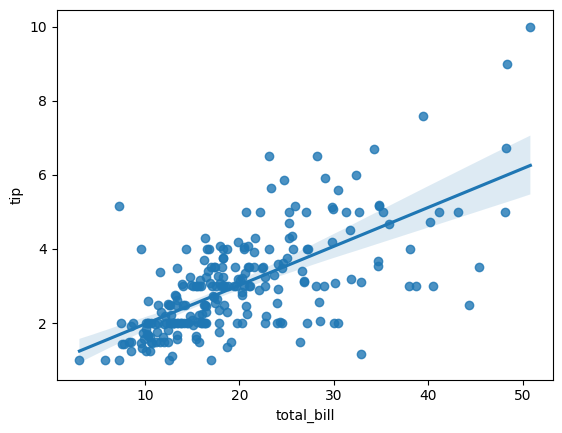

In [23]:
# axes level
# hue parameter is not available
sns.regplot(data=tips,x='total_bill',y='tip')

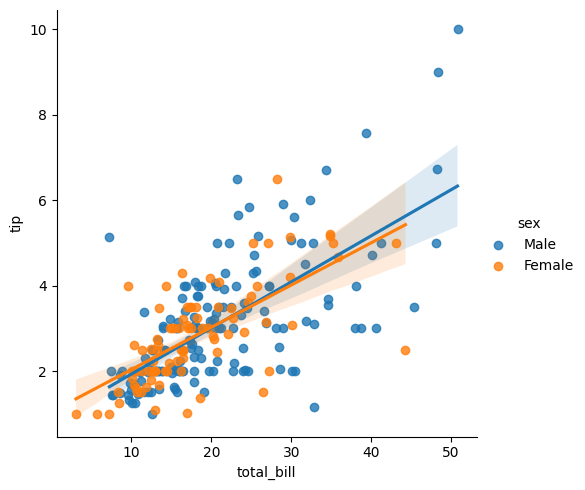

In [24]:
sns.lmplot(data=tips,x='total_bill',y='tip',hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

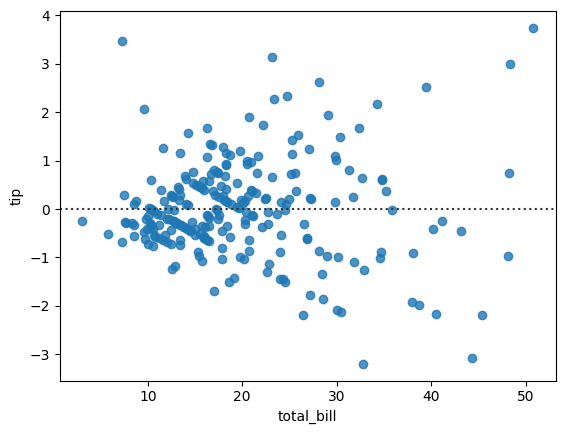

In [25]:
# residplot
sns.residplot(data=tips,x='total_bill',y='tip')

### A second way to plot Facet plots -> FacetGrid

### Faceting with catplot — col and row

So far every `catplot(kind=...)` produced a single panel. The moment you add `col='smoker'` and `row='time'`, the same call multiplies itself into a **grid of panels** — one for every combination of the two faceting columns (here 2 × 2 = 4 panels). Faceting is more powerful than a `hue` mapping: rather than splitting colors inside one crowded axes, each category gets its *own* clean panel, so the shapes of all the boxplots remain legible. You can combine `kind`, `hue`, `col` and `row` freely — e.g. a violin per `day` (cols) for each `time` (rows), colored by `sex`. Facets answer the truly multi-variate question: *does the pattern hold for both smokers and non-smokers, at lunch and at dinner?* Whenever a figure-level function feels cramped, reach for `col=` and `row=` before you give up on readability.

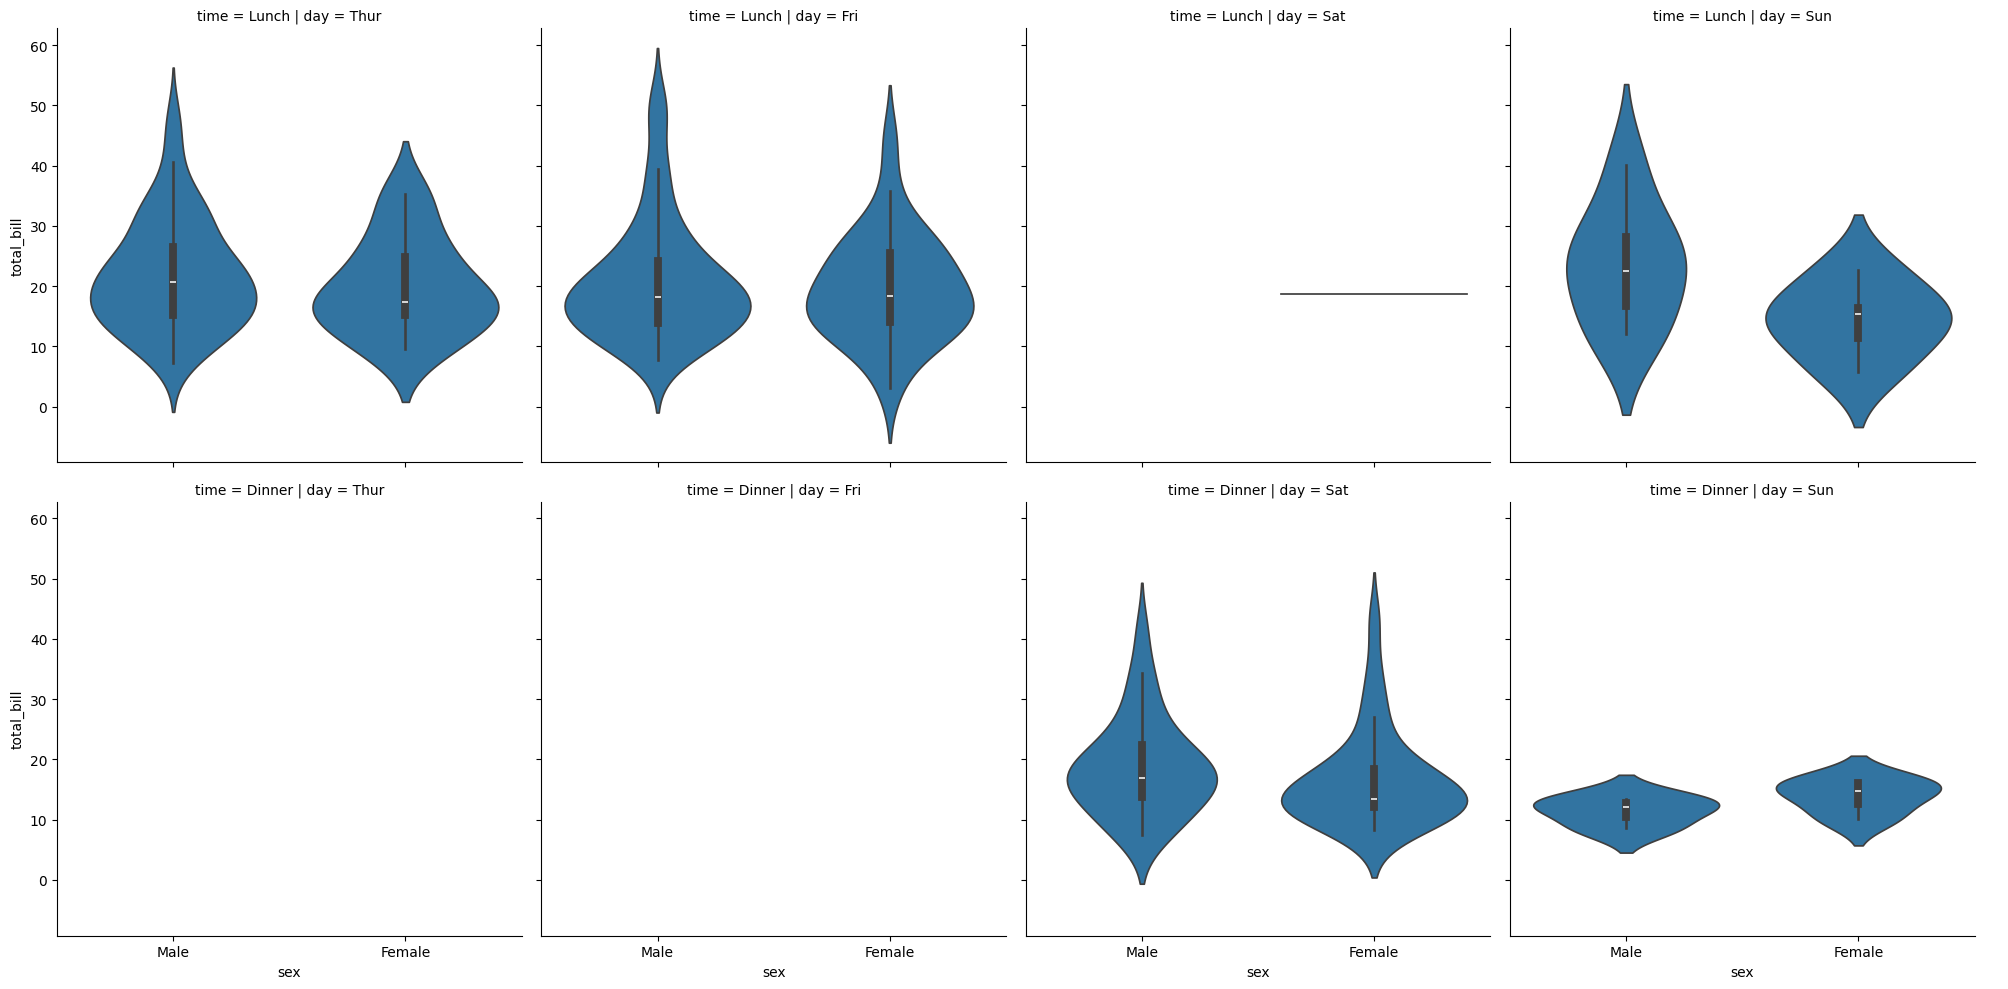

In [26]:
# figure level -> relplot -> displot -> catplot -> lmplot
sns.catplot(data=tips,x='sex',y='total_bill',kind='violin',col='day',row='time')

## 🔬 Deep Dive : FacetGrid / PairGrid / JointGrid

```python
g = sns.FacetGrid(data=tips, col='day', row='time', hue='smoker')
g.map(sns.boxplot, 'total_bill', 'tip')            # custom per-facet plot

sns.pairplot(iris, hue='species')                  # all numeric pairs
g = sns.PairGrid(data=iris, hue='species')
g.map(sns.scatterplot); g.map_diag(sns.histplot)   # upper/lower choices

sns.jointplot(data=tips, x='total_bill', y='tip', kind='hist', hue='sex')
g = sns.JointGrid(data=tips, x='total_bill', y='tip')
g.plot(sns.kdeplot, sns.violinplot)
```

- FacetGrid — manual col×row×hue facet control + g.map(fn,...)
- PairGrid — every numeric×numeric pair matrix (diag=hist)
- pairplot — convenient default version
- JointGrid — joint distribution 2D + marginals (jointplot default)
- g.map computes plotting per facet
- utility: multivariate pattern inspection in one window
- color/semantics channel use groups
- export to fig via .fig

C:\Users\RAVNOOR SINGH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


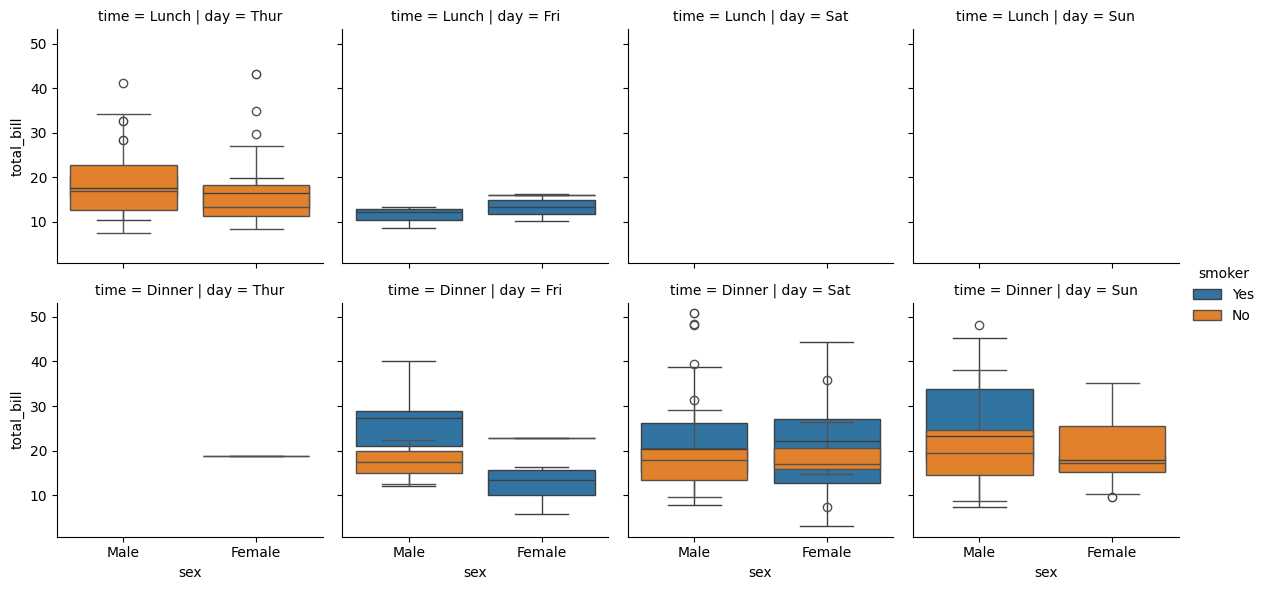

In [27]:
g = sns.FacetGrid(data=tips,col='day',row='time',hue='smoker')
g.map(sns.boxplot,'sex','total_bill')
g.add_legend()

In [28]:
# height and aspect

### Plotting Pairwise Relationship (PairGrid Vs Pairplot)

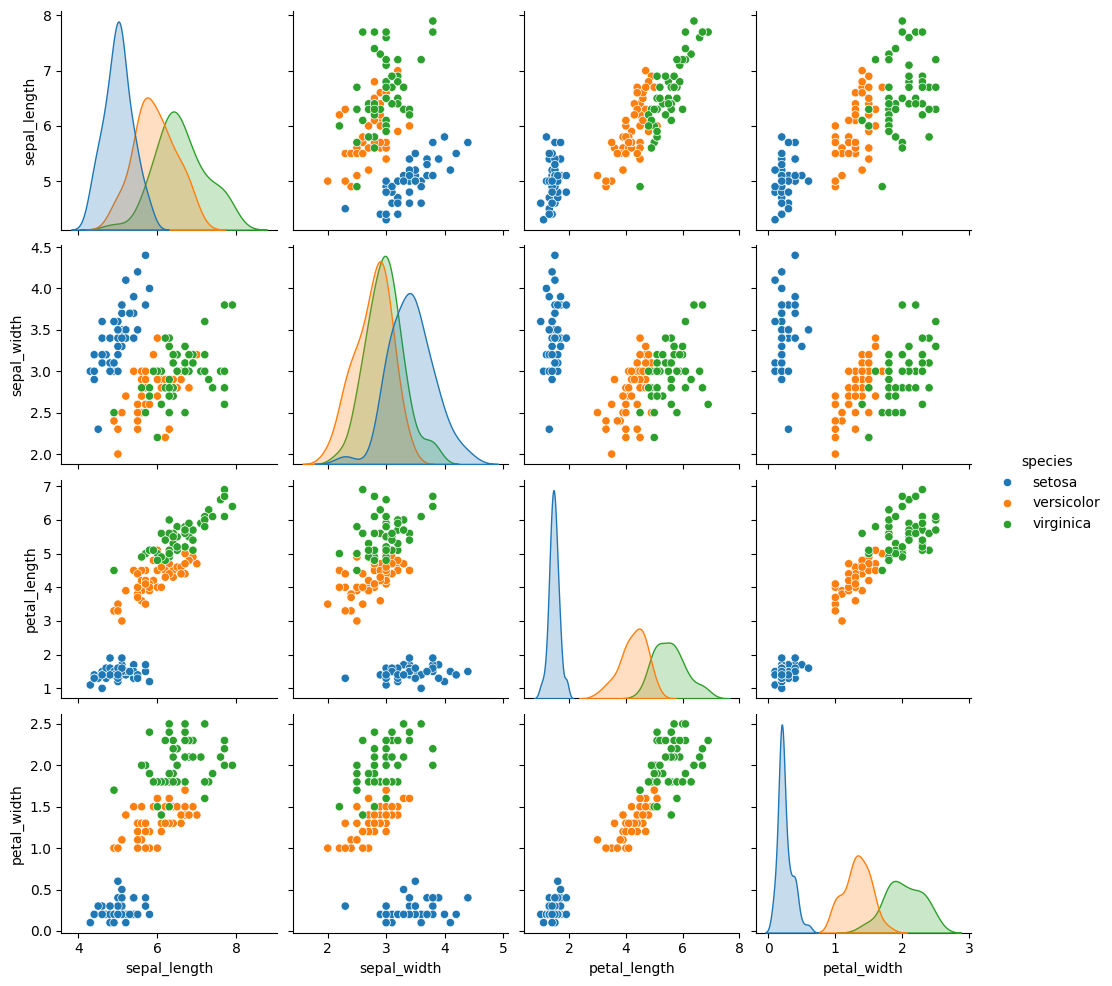

In [29]:
sns.pairplot(iris,hue='species')

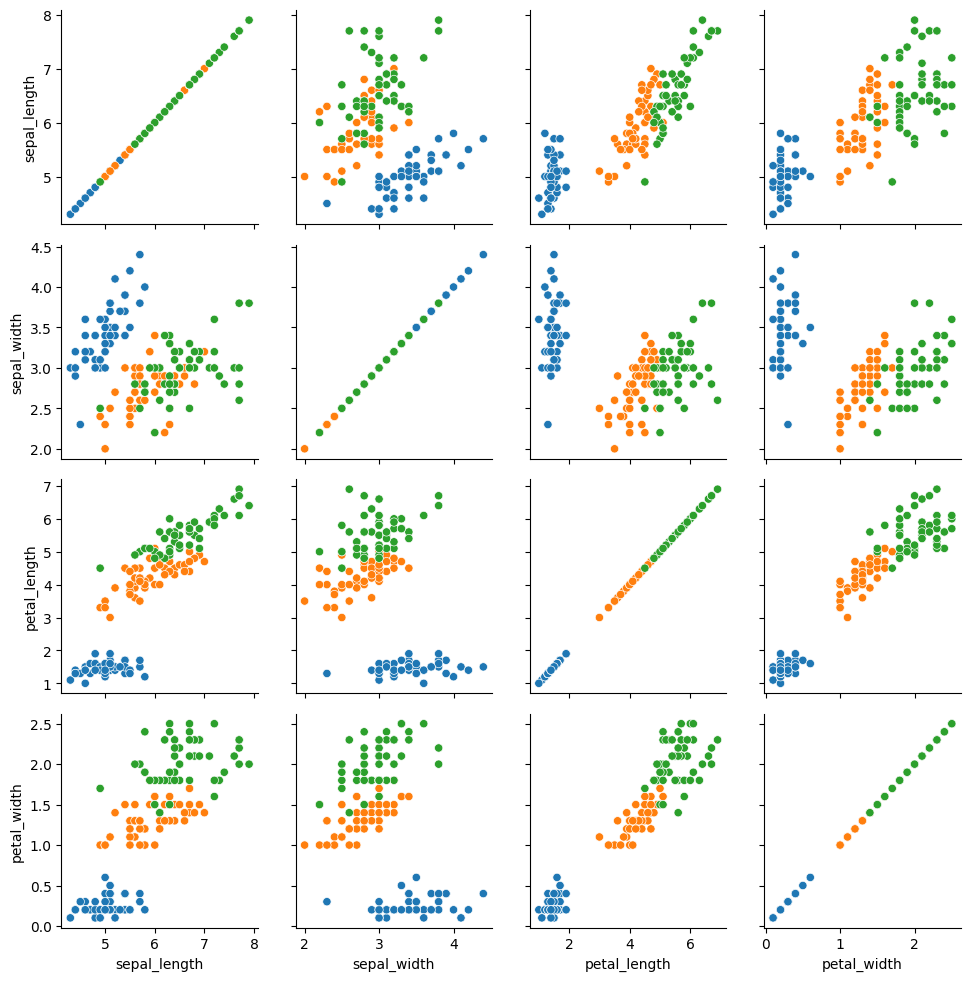

In [30]:
# pair grid
g = sns.PairGrid(data=iris,hue='species')
# g.map
g.map(sns.scatterplot)

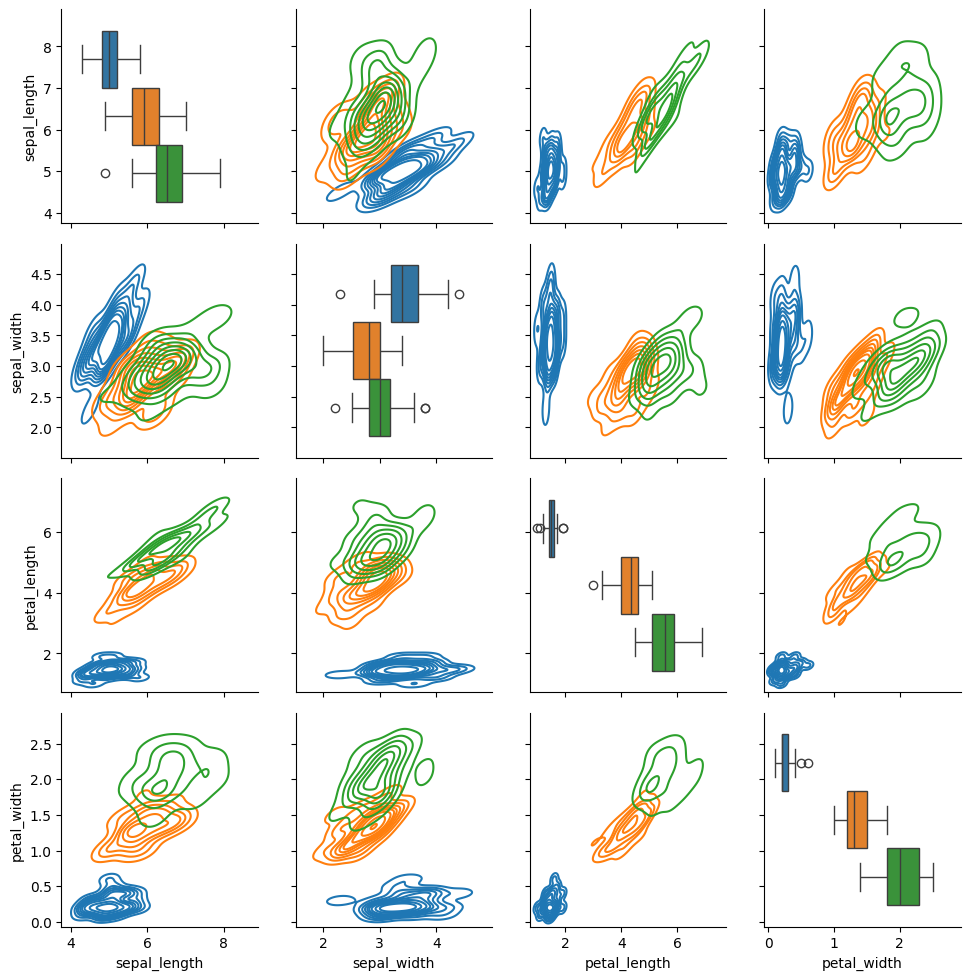

In [31]:
# map_diag -> map_offdiag
g = sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.boxplot)
g.map_offdiag(sns.kdeplot)

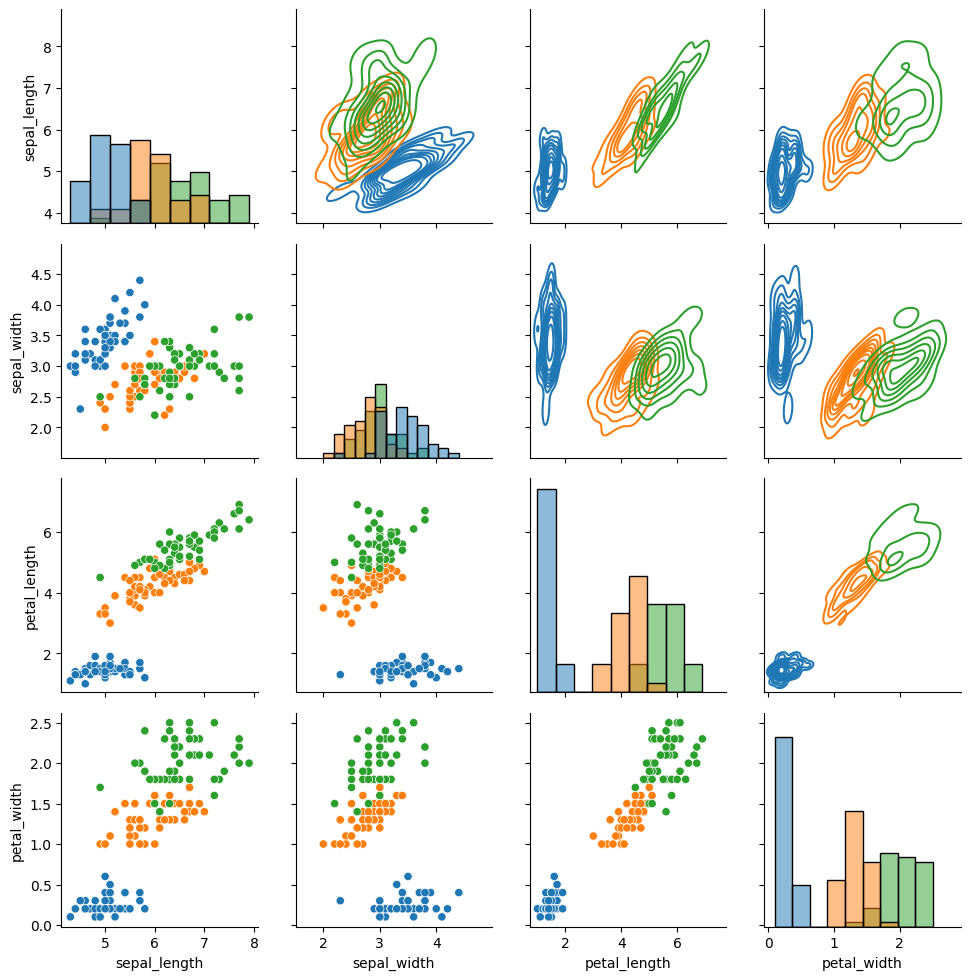

In [32]:
# map_diag -> map_upper -> map_lower
g = sns.PairGrid(data=iris,hue='species')
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)

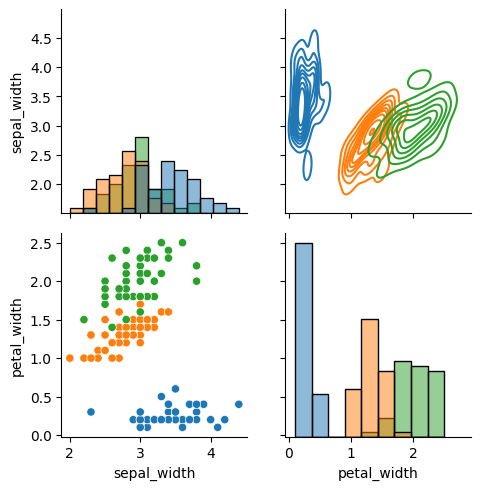

In [33]:
# vars
g = sns.PairGrid(data=iris,hue='species',vars=['sepal_width','petal_width'])
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)

### JointGrid Vs Jointplot

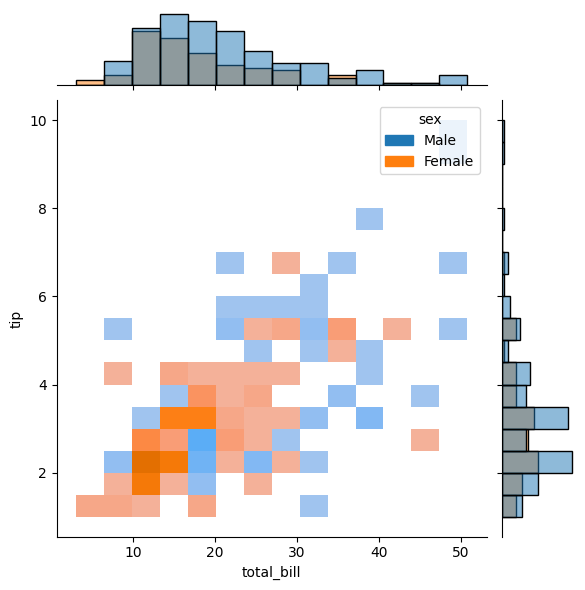

In [34]:
sns.jointplot(data=tips,x='total_bill',y='tip',kind='hist',hue='sex')

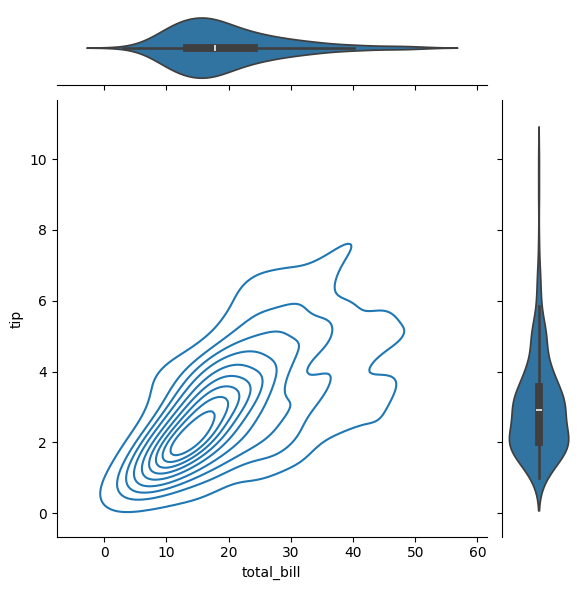

In [35]:
g = sns.JointGrid(data=tips,x='total_bill',y='tip')
g.plot(sns.kdeplot,sns.violinplot)

### Utility Functions

## 🔬 Deep Dive : Built-in datasets & utility

```python
sns.get_dataset_names()            # list available datasets
sns.load_dataset('planets')        # load by name (needs internet)
```

- seaborn bundles sample datasets (tips, iris, titanic, planets, penguins...)
- load_dataset — read into DataFrame (from remote)
- get_dataset_names — view inventory
- Perfect quick prototyping without files
- offline fallback — pd.read_csv('…local…')
- machine learning demo datasets standard
- exercise data used across this course

In [36]:
# get dataset names
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [37]:
# load dataset
sns.load_dataset('planets')

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


## Summary

This notebook completed your tour of Seaborn's categorical, regression and multi-panel tools. You learned the three families of categorical plots — scatter (`stripplot` with `jitter`, `swarmplot`), distribution (`boxplot` with its five-number summary, `violinplot` as box+KDE), and estimate (`barplot`/`pointplot` with error bars, `countplot` for pure counts) — all reachable through the single figure-level function `sns.catplot(kind=...)`. You saw how `hue`, `order`, `saturation`, `split` and `estimator` customize each kind, and how `col=`+`row=` turn them into facet grids. Regression entered the mix via `regplot` (axes-level, line + confidence band), `lmplot` (figure-level with hue/facets) and `residplot` (model-fit diagnosis). Finally you mastered the grid objects: `FacetGrid` with `g.map` and `add_legend`, `PairGrid` with `map_diag`/`map_upper`/`map_lower` (and the one-line `pairplot`), and `JointGrid` with bivariate-plus-marginals (`jointplot`). Along the way, `sns.get_dataset_names()` and `sns.load_dataset()` unlocked Seaborn's built-in data. You can now go from raw tips to faceted, modelled, publication-ready multi-panel figures.